# World Database — DuckDB Query Notebook

This notebook queries the **world.duckdb** database (3 tables: `city`, `country`, `countrylanguage`) using **DuckDB**.

- **5 Basic** queries (fundamentals: SELECT, WHERE, ORDER BY, COUNT, DISTINCT)
- **10 Intermediate** queries (JOINs, GROUP BY, subqueries, aggregations)
- **5 Advanced** queries (window functions, CTEs, correlation, set operations)

Plotting is handled by the decoupled `world_plots.py` module.

---
## Setup

In [1]:
import duckdb
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Connect to the database
con = duckdb.connect('world.duckdb', read_only=True)

# Helper: run SQL, return DataFrame, and display it nicely
def run(sql: str, show: bool = True) -> pd.DataFrame:
    df = con.execute(sql).fetchdf()
    if show:
        display(df)
    return df

# Import all plotting helpers
from world_plots import *

print('Connected to world.duckdb')
print('Tables:', con.execute("SHOW TABLES").fetchdf()['name'].tolist())

Connected to world.duckdb
Tables: ['city', 'country', 'countrylanguage']


---
# BASIC QUERIES (1–5)

### Basic 1 — List All Distinct Continents

**What are we doing?**  
Retrieve the unique continents stored in the `country` table to understand the geographic coverage of the dataset.

In [2]:
sql = """
SELECT DISTINCT continent
FROM   country
ORDER  BY continent;
"""

df = run(sql)

,Continent
0,Africa
1,Antarctica
2,Asia
3,Europe
4,North America
5,Oceania
6,South America


### Basic 2 — Top 10 Most Populated Countries

**What are we doing?**  
Find the 10 countries with the largest populations, ordered descending.

In [3]:
sql = """
SELECT   name,
         continent,
         population
FROM     country
WHERE    population > 0
ORDER BY population DESC
LIMIT    10;
"""

df = run(sql)

,Name,Continent,Population
0,United States,North America,278357000
1,Brazil,South America,170115000
2,Bangladesh,Asia,129155000
3,Vietnam,Asia,79832000
4,Turkey,Asia,66591000
5,Ukraine,Europe,50456000
6,South Africa,Africa,40377000
7,Argentina,South America,37032000
8,Tanzania,Africa,33517000
9,Canada,North America,31147000


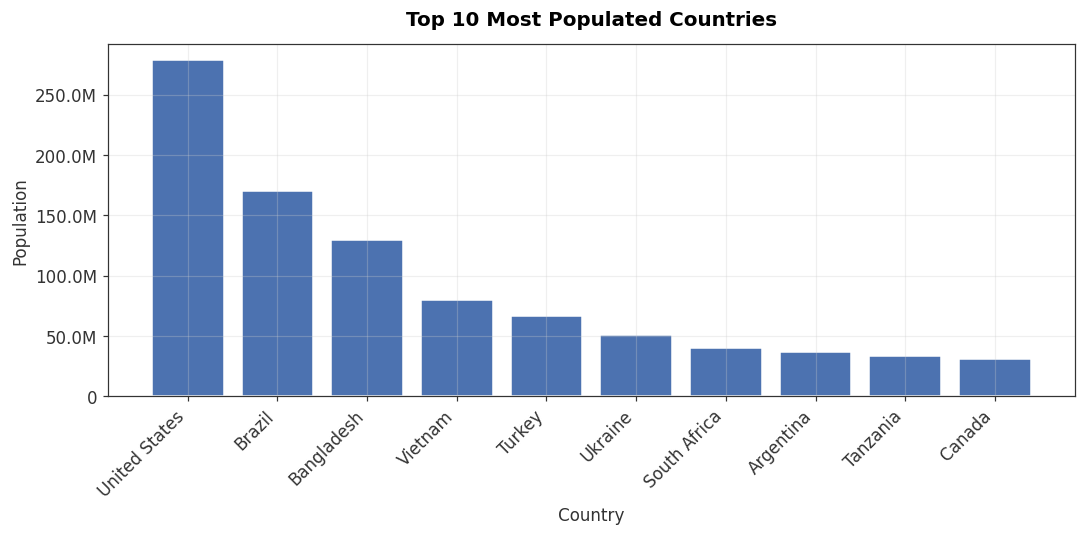

In [5]:
plot_bar(df, x='Name', y='Population',
         title='Top 10 Most Populated Countries',
         xlabel='Country', ylabel='Population',
         fmt_y_millions=True, rotate_labels=45)

### Basic 3 — Count the Number of Cities per Country (Top 15)

**What are we doing?**  
Count how many cities each country has in the database and show the top 15.

In [6]:
sql = """
SELECT   co.name       AS country,
         COUNT(ci.id)  AS city_count
FROM     city ci
JOIN     country co ON ci.countrycode = co.code
GROUP BY co.name
ORDER BY city_count DESC
LIMIT    15;
"""

df = run(sql)

,country,city_count
0,United States,274
1,Brazil,250
2,Turkey,62
3,Ukraine,57
4,Argentina,57
5,Canada,49
6,South Africa,44
7,Taiwan,42
8,Venezuela,41
9,Chile,29


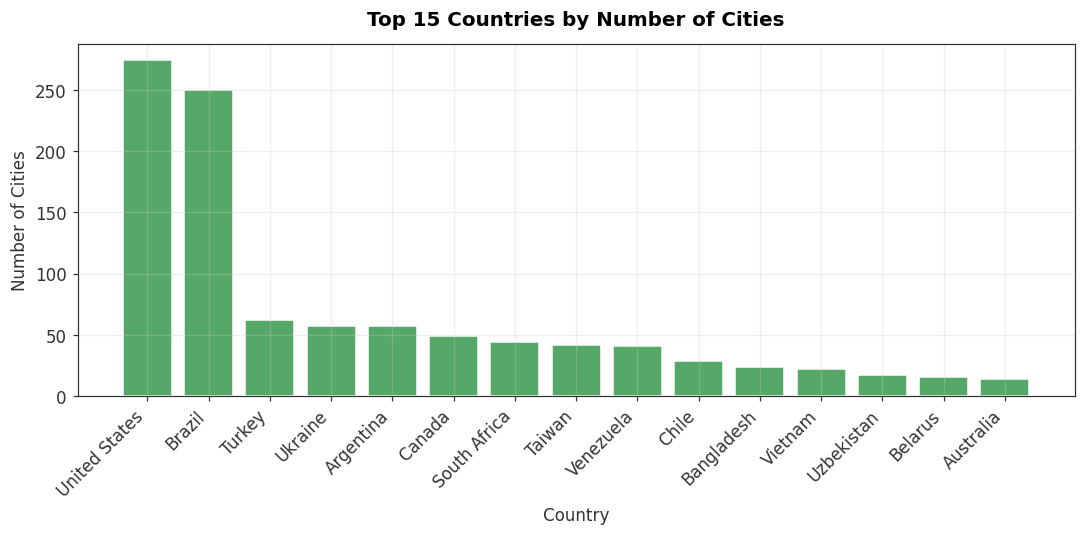

In [7]:
plot_bar(df, x='country', y='city_count',
         title='Top 15 Countries by Number of Cities',
         xlabel='Country', ylabel='Number of Cities',
         color='#55A868', rotate_labels=45)

### Basic 4 — Countries with Life Expectancy Above 78

**What are we doing?**  
Filter countries whose life expectancy exceeds 78 years, sorted by life expectancy descending.

In [8]:
sql = """
SELECT   name,
         continent,
         lifeexpectancy
FROM     country
WHERE    lifeexpectancy > 78
ORDER BY lifeexpectancy DESC;
"""

df = run(sql)

,Name,Continent,LifeExpectancy
0,Andorra,Europe,83.5
1,Australia,Oceania,79.8
2,Switzerland,Europe,79.6
3,Canada,North America,79.4
4,Aruba,North America,78.4
5,"Virgin Islands, U.S.",North America,78.1


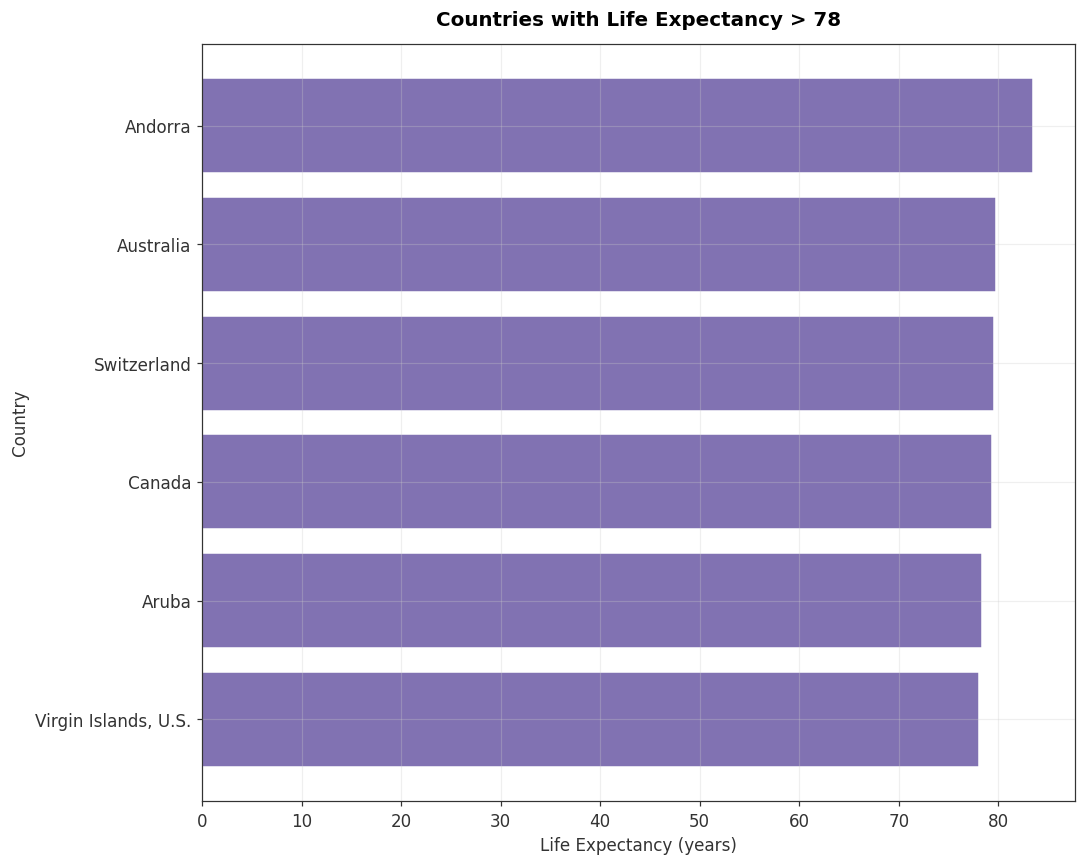

In [10]:
plot_bar(df, x='Name', y='LifeExpectancy',
         title='Countries with Life Expectancy > 78',
         xlabel='Country', ylabel='Life Expectancy (years)',
         horizontal=True, figsize=(10, 8), color='#8172B2')

### Basic 5 — Find the Most Populated City in the World

**What are we doing?**  
Identify the single most populated city along with its country.

In [11]:
sql = """
SELECT   ci.name       AS city,
         co.name       AS country,
         ci.district,
         ci.population
FROM     city ci
JOIN     country co ON ci.countrycode = co.code
ORDER BY ci.population DESC
LIMIT    1;
"""

df = run(sql)

,city,country,District,Population
0,São Paulo,Brazil,São Paulo,9968485


---
# INTERMEDIATE QUERIES (6–15)

### Intermediate 1 — Top 10 Countries with Their Capital Cities

**What are we doing?**  
Join `country` to `city` via the `capital` foreign key to show each country's capital and both populations.

In [12]:
sql = """
SELECT   co.name              AS country,
         ci.name              AS capital_city,
         co.population        AS country_pop,
         ci.population        AS capital_pop
FROM     country co
JOIN     city ci ON co.capital = ci.id
WHERE    co.population > 0
ORDER BY co.population DESC
LIMIT    10;
"""

df = run(sql)

,country,capital_city,country_pop,capital_pop
0,United States,Washington,278357000,572059
1,Brazil,Brasília,170115000,1969868
2,Bangladesh,Dhaka,129155000,3612850
3,Vietnam,Hanoi,79832000,1410000
4,Turkey,Ankara,66591000,3038159
5,Ukraine,Kyiv,50456000,2624000
6,South Africa,Pretoria,40377000,658630
7,Argentina,Buenos Aires,37032000,2982146
8,Tanzania,Dodoma,33517000,189000
9,Canada,Ottawa,31147000,335277


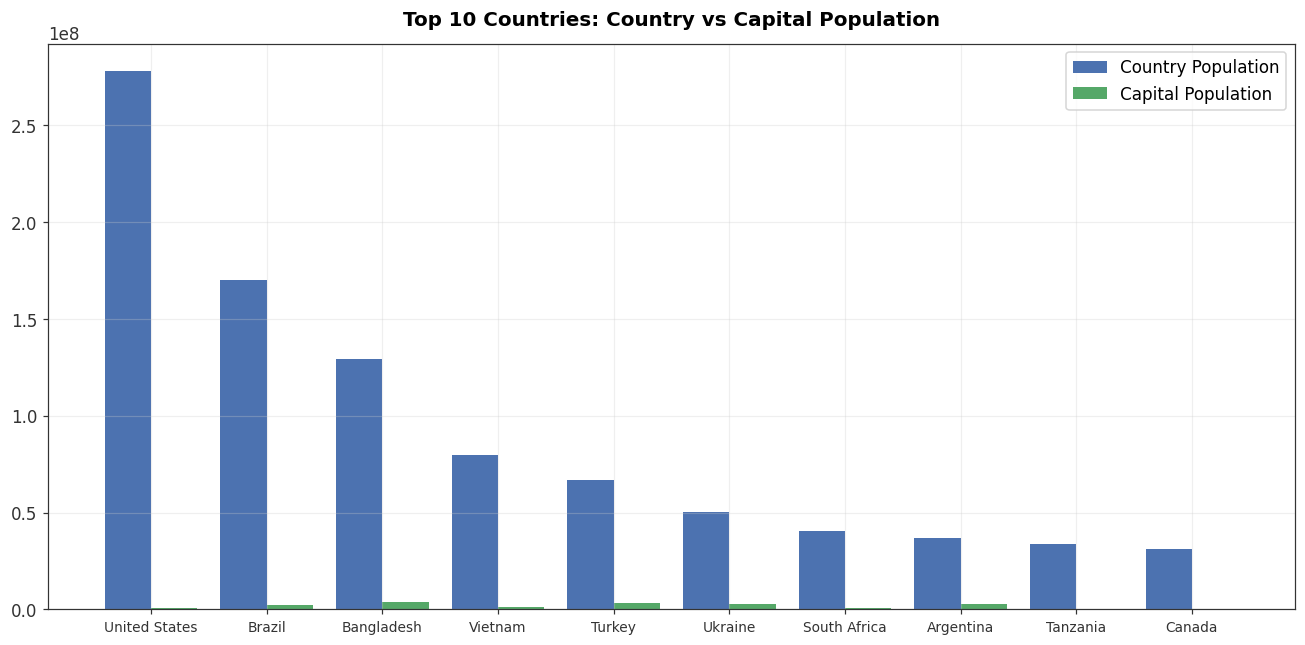

In [13]:
plot_grouped_bar(df, category='country',
                 values=['country_pop', 'capital_pop'],
                 labels=['Country Population', 'Capital Population'],
                 title='Top 10 Countries: Country vs Capital Population',
                 figsize=(12, 6))

### Intermediate 2 — Average Life Expectancy by Continent

**What are we doing?**  
Compute the mean life expectancy for each continent, excluding NULLs.

In [14]:
sql = """
SELECT   continent,
         ROUND(AVG(lifeexpectancy), 1) AS avg_life_exp,
         COUNT(*)                      AS num_countries
FROM     country
WHERE    lifeexpectancy IS NOT NULL
GROUP BY continent
ORDER BY avg_life_exp DESC;
"""

df = run(sql)

,Continent,avg_life_exp,num_countries
0,North America,74.4,14
1,Europe,73.9,10
2,South America,71.0,6
3,Oceania,70.2,5
4,Asia,65.3,13
5,Africa,46.6,12


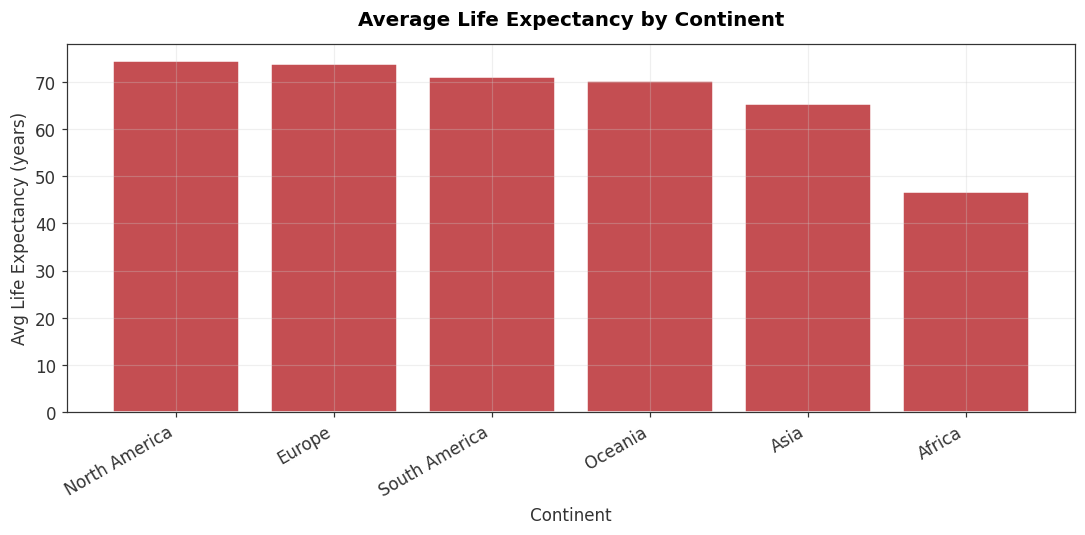

In [16]:
plot_bar(df, x='Continent', y='avg_life_exp',
         title='Average Life Expectancy by Continent',
         xlabel='Continent', ylabel='Avg Life Expectancy (years)',
         color='#C44E52', rotate_labels=30)

### Intermediate 3 — GNP per Capita: Top 15 Countries

**What are we doing?**  
Calculate GNP per capita (GNP / population) and rank the richest countries.

In [17]:
sql = """
SELECT   name,
         continent,
         gnp,
         population,
         ROUND(gnp * 1000000.0 / population, 2) AS gnp_per_capita
FROM     country
WHERE    population > 0
  AND    gnp > 0
ORDER BY gnp_per_capita DESC
LIMIT    15;
"""

df = run(sql)

,Name,Continent,GNP,Population,gnp_per_capita
0,Switzerland,Europe,264478.0,7160400,36936.20
1,Bermuda,North America,2328.0,65000,35815.38
2,Brunei,Asia,11705.0,328000,35685.98
3,United States,North America,8510700.0,278357000,30574.77
4,"Virgin Islands, British",North America,612.0,21000,29142.86
5,Austria,Europe,211860.0,8091800,26182.06
6,Belgium,Europe,249704.0,10239000,24387.54
7,Andorra,Europe,1630.0,78000,20897.44
8,Canada,North America,598862.0,31147000,19226.96
9,Australia,Oceania,351182.0,18886000,18594.83


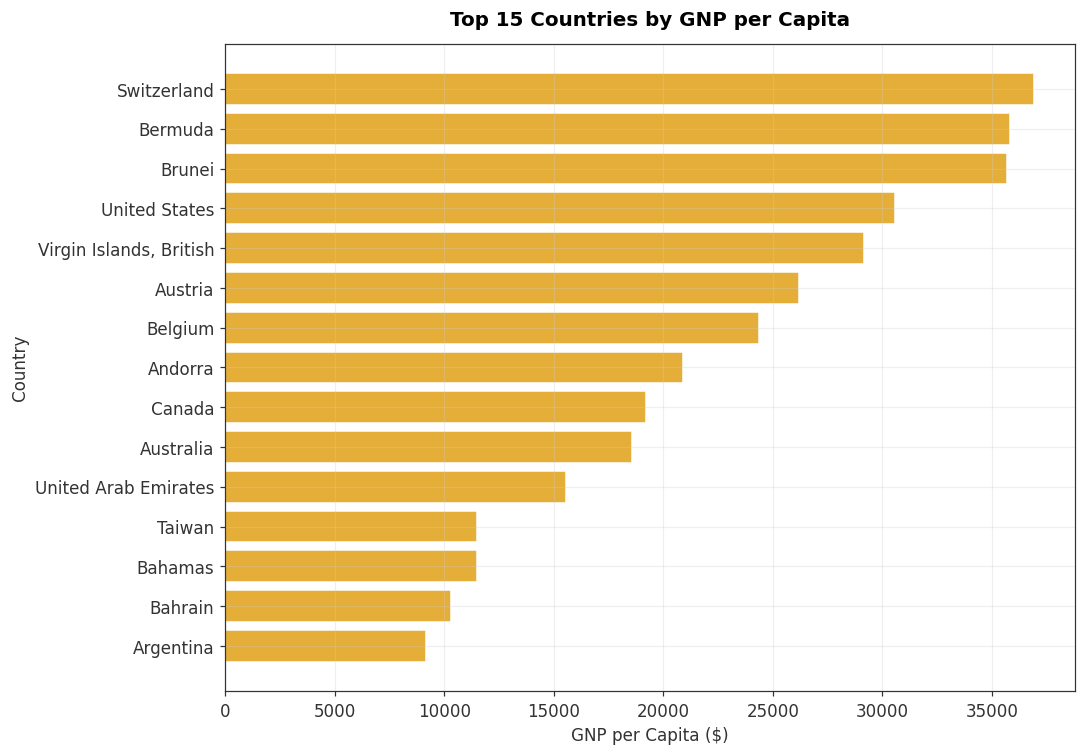

In [19]:
plot_bar(df, x='Name', y='gnp_per_capita',
         title='Top 15 Countries by GNP per Capita',
         xlabel='Country', ylabel='GNP per Capita ($)',
         horizontal=True, figsize=(10, 7), color='#E5AE38')

### Intermediate 4 — Languages Spoken in 10+ Countries

**What are we doing?**  
Find languages that appear in 10 or more countries in the `countrylanguage` table.

In [20]:
sql = """
SELECT   language,
         COUNT(DISTINCT countrycode) AS num_countries
FROM     countrylanguage
GROUP BY language
HAVING   COUNT(DISTINCT countrycode) >= 10
ORDER BY num_countries DESC;
"""

df = run(sql)

,Language,num_countries
0,English,60
1,Arabic,33
2,Spanish,28
3,French,25
4,German,19
5,Chinese,19
6,Russian,17
7,Italian,15
8,Creole English,14
9,Ful,12


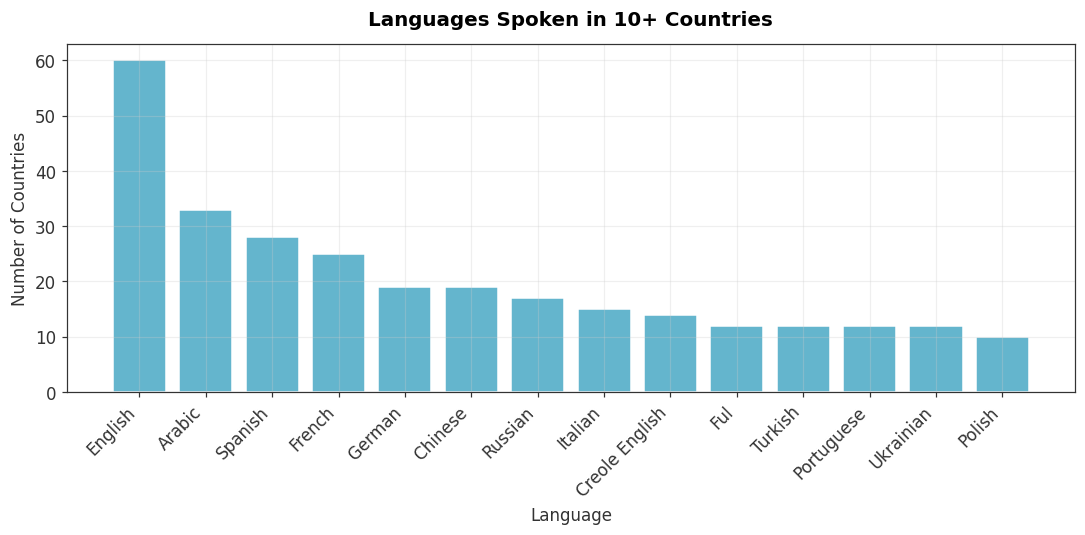

In [21]:
plot_bar(df, x='Language', y='num_countries',
         title='Languages Spoken in 10+ Countries',
         xlabel='Language', ylabel='Number of Countries',
         color='#64B5CD', rotate_labels=45)

### Intermediate 5 — Population Distribution by Continent

**What are we doing?**  
Aggregate total population per continent and show as a pie chart.

In [22]:
sql = """
SELECT   continent,
         SUM(population) AS total_pop
FROM     country
GROUP BY continent
ORDER BY total_pop DESC;
"""

df = run(sql)

,Continent,total_pop
0,Asia,379748000.0
1,North America,312306000.0
2,South America,258194000.0
3,Africa,168940000.0
4,Europe,112466300.0
5,Oceania,19351600.0
6,Antarctica,0.0


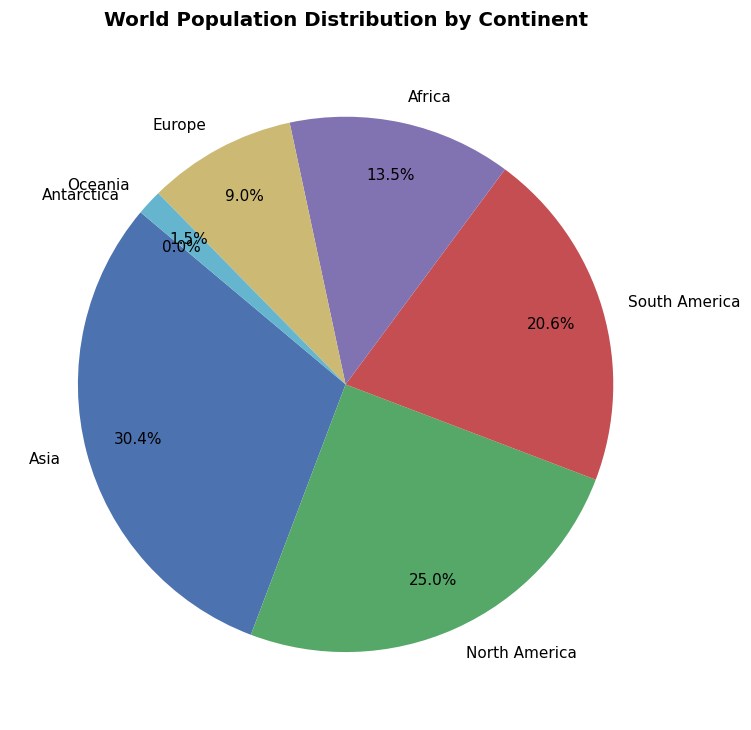

In [24]:
plot_pie(df, labels_col='Continent', values_col='total_pop',
         title='World Population Distribution by Continent')

### Intermediate 6 — Population Density: Top 20 Countries

**What are we doing?**  
Compute population density (people per km²) and rank the most densely populated countries.

In [25]:
sql = """
SELECT   name,
         continent,
         population,
         surfacearea,
         ROUND(population / surfacearea, 1) AS density
FROM     country
WHERE    surfacearea > 0
  AND    population  > 0
ORDER BY density DESC
LIMIT    20;
"""

df = run(sql)

,Name,Continent,Population,SurfaceArea,density
0,Holy See (Vatican City State),Europe,1000,0.4,2500.0
1,Bermuda,North America,65000,53.0,1226.4
2,Bangladesh,Asia,129155000,143998.0,896.9
3,Bahrain,Asia,617000,694.0,889.0
4,Barbados,North America,270000,430.0,627.9
5,Taiwan,Asia,22256000,36188.0,615.0
6,Aruba,North America,103000,193.0,533.7
7,Tuvalu,Oceania,12000,26.0,461.5
8,American Samoa,Oceania,68000,199.0,341.7
9,Belgium,Europe,10239000,30518.0,335.5


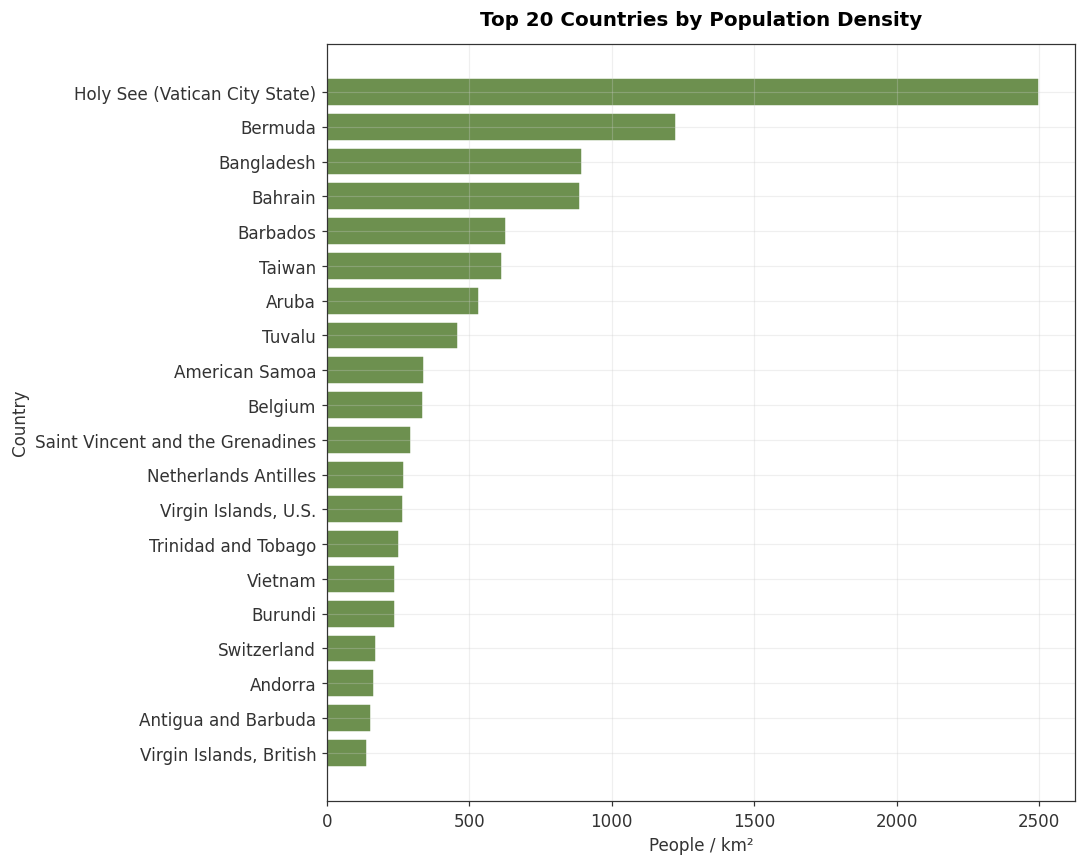

In [27]:
plot_bar(df, x='Name', y='density',
         title='Top 20 Countries by Population Density',
         xlabel='Country', ylabel='People / km²',
         horizontal=True, figsize=(10, 8), color='#6D904F')

### Intermediate 7 — Dependent Territories (No Independence Year)

**What are we doing?**  
List territories that have no independence year (i.e. they are still dependencies or overseas territories).

In [28]:
sql = """
SELECT   name,
         continent,
         region,
         governmentform,
         population
FROM     country
WHERE    indepyear IS NULL
ORDER BY population DESC;
"""

df = run(sql)

,Name,Continent,Region,GovernmentForm,Population
0,Netherlands Antilles,North America,Caribbean,Nonmetropolitan Territory of The Netherlands,217000
1,Aruba,North America,Caribbean,Nonmetropolitan Territory of The Netherlands,103000
2,"Virgin Islands, U.S.",North America,Caribbean,US Territory,93000
3,American Samoa,Oceania,Polynesia,US Territory,68000
4,Bermuda,North America,North America,Dependent Territory of the UK,65000
5,"Virgin Islands, British",North America,Caribbean,Dependent Territory of the UK,21000
6,Wallis and Futuna,Oceania,Polynesia,Nonmetropolitan Territory of France,15000
7,Anguilla,North America,Caribbean,Dependent Territory of the UK,8000
8,Cocos (Keeling) Islands,Oceania,Australia and New Zealand,Territory of Australia,600
9,Antarctica,Antarctica,Antarctica,Co-administrated,0


### Intermediate 8 — Number of Official Languages per Country (Top 10)

**What are we doing?**  
Count official languages per country and show which countries have the most.

In [29]:
sql = """
SELECT   co.name                             AS country,
         COUNT(cl.language)                   AS official_lang_count,
         STRING_AGG(cl.language, ', '
                    ORDER BY cl.percentage DESC) AS languages
FROM     countrylanguage cl
JOIN     country co ON cl.countrycode = co.code
WHERE    cl.isofficial = true
GROUP BY co.name
ORDER BY official_lang_count DESC
LIMIT    10;
"""

df = run(sql)

,country,official_lang_count,languages
0,Switzerland,4,"German, French, Italian, Romansh"
1,South Africa,4,"Zulu, Xhosa, Afrikaans, English"
2,Belgium,3,"Dutch, French, German"
3,Bolivia,3,"Spanish, Ketua, Aimará"
4,Vanuatu,3,"Bislama, English, French"
5,Tuvalu,2,"Tuvalu, English"
6,Belarus,2,"Belorussian, Russian"
7,Samoa,2,"Samoan, English"
8,Burundi,2,"Kirundi, French"
9,American Samoa,2,"Samoan, English"


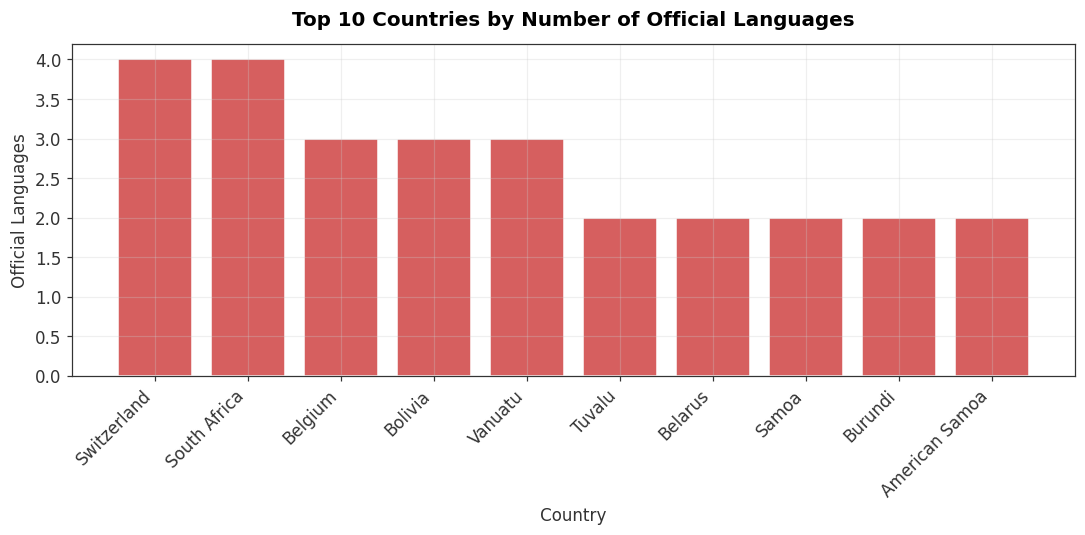

In [30]:
plot_bar(df, x='country', y='official_lang_count',
         title='Top 10 Countries by Number of Official Languages',
         xlabel='Country', ylabel='Official Languages',
         color='#D65F5F', rotate_labels=45)

### Intermediate 9 — Largest City in Each Continent

**What are we doing?**  
Use a subquery to find the single most populated city on every continent.

In [31]:
sql = """
SELECT   co.continent,
         ci.name        AS city,
         co.name        AS country,
         ci.population
FROM     city ci
JOIN     country co ON ci.countrycode = co.code
WHERE    ci.population = (
             SELECT MAX(ci2.population)
             FROM   city ci2
             JOIN   country co2 ON ci2.countrycode = co2.code
             WHERE  co2.continent = co.continent
         )
ORDER BY ci.population DESC;
"""

df = run(sql)

,Continent,city,country,Population
0,South America,São Paulo,Brazil,9968485
1,Asia,Istanbul,Turkey,8787958
2,North America,New York,United States,8008278
3,Oceania,Sydney,Australia,3276207
4,Europe,Kyiv,Ukraine,2624000
5,Africa,Cape Town,South Africa,2352121


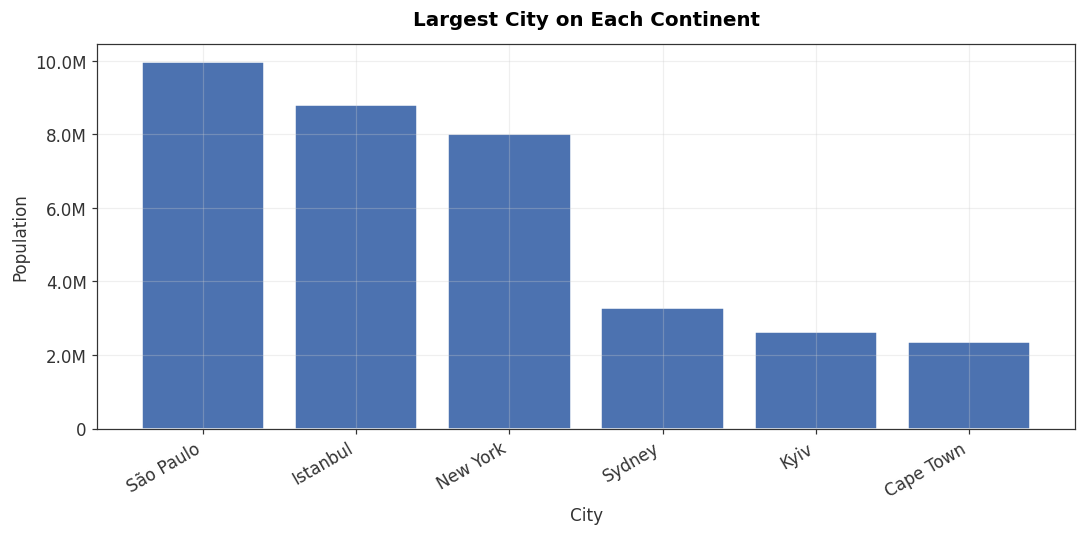

In [33]:
plot_bar(df, x='city', y='Population',
         title='Largest City on Each Continent',
         xlabel='City', ylabel='Population',
         fmt_y_millions=True, rotate_labels=30)

### Intermediate 10 — GNP Growth: Countries Where GNP Increased

**What are we doing?**  
Compare current GNP vs. old GNP (`gnpold`) and find countries with the largest absolute growth.

In [34]:
sql = """
SELECT   name,
         continent,
         gnp,
         gnpold,
         ROUND(gnp - gnpold, 2)                       AS gnp_growth,
         ROUND((gnp - gnpold) / gnpold * 100, 1)      AS growth_pct
FROM     country
WHERE    gnp IS NOT NULL
  AND    gnpold IS NOT NULL
  AND    gnpold > 0
ORDER BY gnp_growth DESC
LIMIT    15;
"""

df = run(sql)

,Name,Continent,GNP,GNPOld,gnp_growth,growth_pct
0,United States,North America,8510700.0,8110900.0,399800.0,4.9
1,Turkey,Asia,210721.0,189122.0,21599.0,11.4
2,Argentina,South America,340238.0,323310.0,16928.0,5.2
3,Switzerland,Europe,264478.0,256092.0,8386.0,3.3
4,Venezuela,South America,95023.0,88434.0,6589.0,7.5
5,Austria,Europe,211860.0,206025.0,5835.0,2.8
6,Belgium,Europe,249704.0,243948.0,5756.0,2.4
7,Bulgaria,Europe,12178.0,10169.0,2009.0,19.8
8,Tunisia,Africa,20026.0,18898.0,1128.0,6.0
9,United Arab Emirates,Asia,37966.0,36846.0,1120.0,3.0


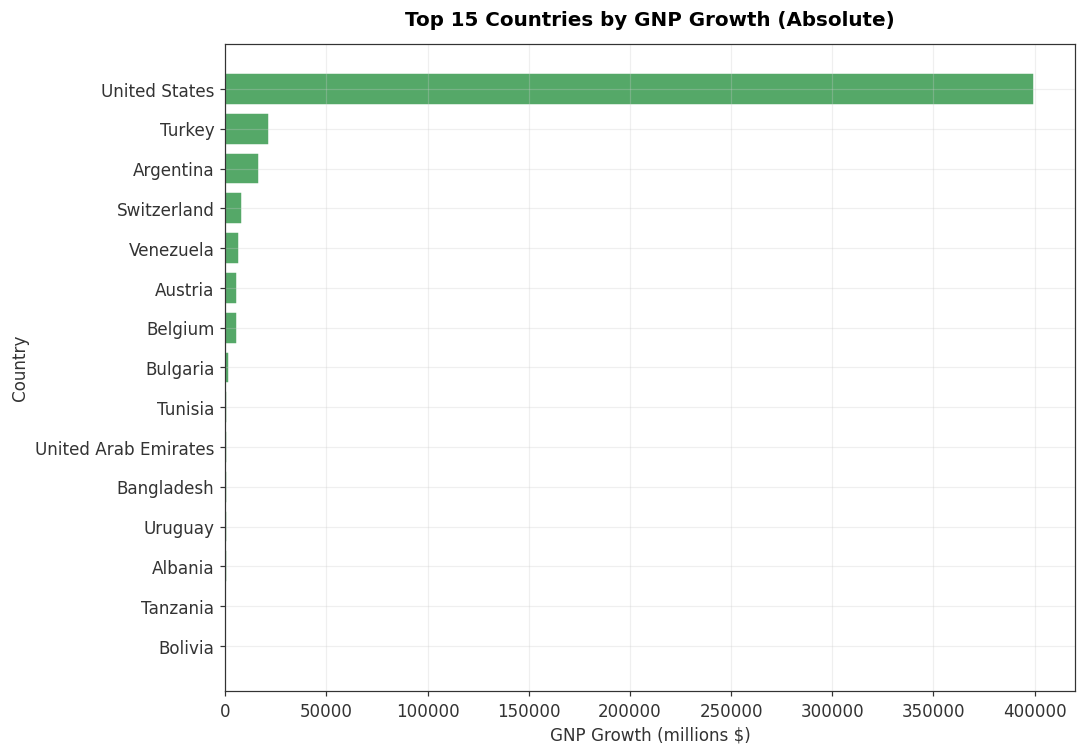

In [36]:
plot_bar(df, x='Name', y='gnp_growth',
         title='Top 15 Countries by GNP Growth (Absolute)',
         xlabel='Country', ylabel='GNP Growth (millions $)',
         horizontal=True, figsize=(10, 7), color='#55A868')

---
# ADVANCED QUERIES (16–20)

### Advanced 1 — Rank Countries Within Each Continent by Population (Window Function)

**What are we doing?**  
Use `RANK() OVER(PARTITION BY continent)` to rank each country within its continent by population, then show the top 3 per continent.

In [42]:
sql = """
WITH ranked AS (
    SELECT  name,
            continent,
            population,
            RANK() OVER (
                PARTITION BY continent
                ORDER BY     population DESC
            ) AS pop_rank
    FROM    country
    WHERE   population > 0
)
SELECT  continent,
        name,
        population,
        pop_rank
FROM    ranked
WHERE   pop_rank <= 3
ORDER BY continent, pop_rank;
"""

df = run(sql)

,Continent,Name,Population,pop_rank
0,Africa,South Africa,40377000,1
1,Africa,Tanzania,33517000,2
2,Africa,Uganda,21778000,3
3,Asia,Bangladesh,129155000,1
4,Asia,Vietnam,79832000,2
5,Asia,Turkey,66591000,3
6,Europe,Ukraine,50456000,1
7,Europe,Yugoslavia,10640000,2
8,Europe,Belgium,10239000,3
9,North America,United States,278357000,1


In [43]:
# Pivot for a grouped view
pivot = df.pivot_table(index='Continent', columns='pop_rank',
                       values='Name', aggfunc='first')
pivot.columns = [f'Rank {int(c)}' for c in pivot.columns]
display(pivot)

,Rank 1,Rank 2,Rank 3
Continent,,,
Africa,South Africa,Tanzania,Uganda
Asia,Bangladesh,Vietnam,Turkey
Europe,Ukraine,Yugoslavia,Belgium
North America,United States,Canada,Trinidad and Tobago
Oceania,Australia,Vanuatu,Samoa
South America,Brazil,Argentina,Venezuela


### Advanced 2 — Countries Where Capital Is NOT the Most Populated City

**What are we doing?**  
Use a CTE to find each country's largest city, then compare it with the capital. Show cases where they differ.

In [44]:
sql = """
WITH biggest_city AS (
    SELECT   countrycode,
             name       AS biggest_city_name,
             population AS biggest_city_pop
    FROM     city
    WHERE    (countrycode, population) IN (
                 SELECT   countrycode, MAX(population)
                 FROM     city
                 GROUP BY countrycode
             )
)
SELECT   co.name           AS country,
         cap.name          AS capital,
         cap.population    AS capital_pop,
         bc.biggest_city_name,
         bc.biggest_city_pop
FROM     country co
JOIN     city cap            ON co.capital = cap.id
JOIN     biggest_city bc     ON co.code    = bc.countrycode
WHERE    cap.name != bc.biggest_city_name
ORDER BY bc.biggest_city_pop DESC
LIMIT    15;
"""

df = run(sql)

,country,capital,capital_pop,biggest_city_name,biggest_city_pop
0,Brazil,Brasília,1969868,São Paulo,9968485
1,Turkey,Ankara,3038159,Istanbul,8787958
2,United States,Washington,572059,New York,8008278
3,Vietnam,Hanoi,1410000,Ho Chi Minh City,3980000
4,Australia,Canberra,322723,Sydney,3276207
5,South Africa,Pretoria,658630,Cape Town,2352121
6,Tanzania,Dodoma,189000,Dar es Salaam,1747000
7,Canada,Ottawa,335277,Montréal,1016376
8,Bolivia,La Paz,758141,Santa Cruz de la Sierra,935361
9,United Arab Emirates,Abu Dhabi,398695,Dubai,669181


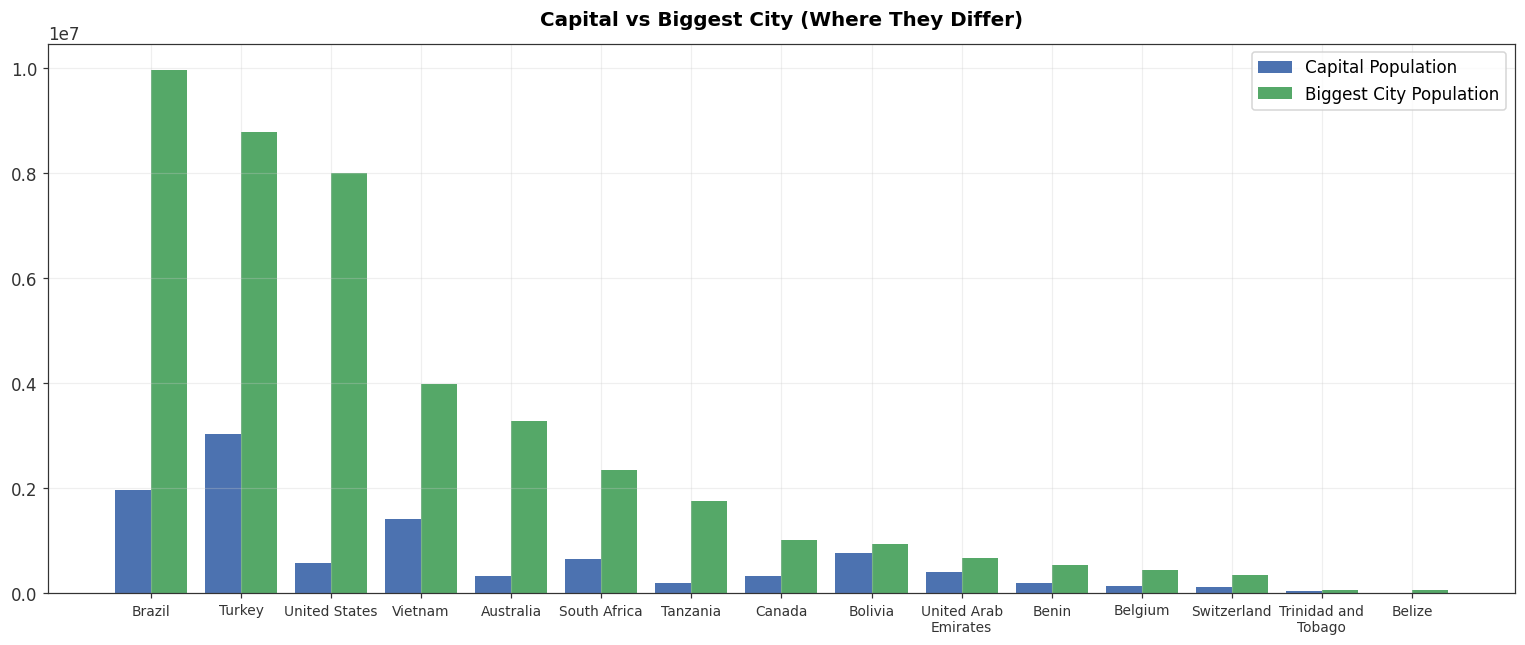

In [45]:
plot_grouped_bar(df, category='country',
                 values=['capital_pop', 'biggest_city_pop'],
                 labels=['Capital Population', 'Biggest City Population'],
                 title='Capital vs Biggest City (Where They Differ)',
                 figsize=(14, 6))

### Advanced 3 — Language Diversity Index per Country

**What are we doing?**  
Compute a *Herfindahl-style* language diversity index:  
`1 - SUM(percentage² / 10000)`.  
A score near 1 means highly diverse; near 0 means one dominant language.

In [46]:
sql = """
WITH diversity AS (
    SELECT   cl.countrycode,
             co.name,
             co.continent,
             COUNT(cl.language)                                   AS num_languages,
             ROUND(1.0 - SUM(cl.percentage * cl.percentage) / 10000, 4)
                                                                  AS diversity_index
    FROM     countrylanguage cl
    JOIN     country co ON cl.countrycode = co.code
    GROUP BY cl.countrycode, co.name, co.continent
)
SELECT   name,
         continent,
         num_languages,
         diversity_index
FROM     diversity
ORDER BY diversity_index DESC
LIMIT    20;
"""

df = run(sql)

,Name,Continent,num_languages,diversity_index
0,United States Minor Outlying Islands,Oceania,1,1.0000
1,Wallis and Futuna,Oceania,2,1.0000
2,Anguilla,North America,1,1.0000
3,"Virgin Islands, British",North America,1,1.0000
4,Holy See (Vatican City State),Europe,1,1.0000
5,Cocos (Keeling) Islands,Oceania,2,1.0000
6,Uganda,Africa,10,0.9279
7,Tanzania,Africa,11,0.9237
8,Zambia,Africa,6,0.8844
9,South Africa,Africa,11,0.8657


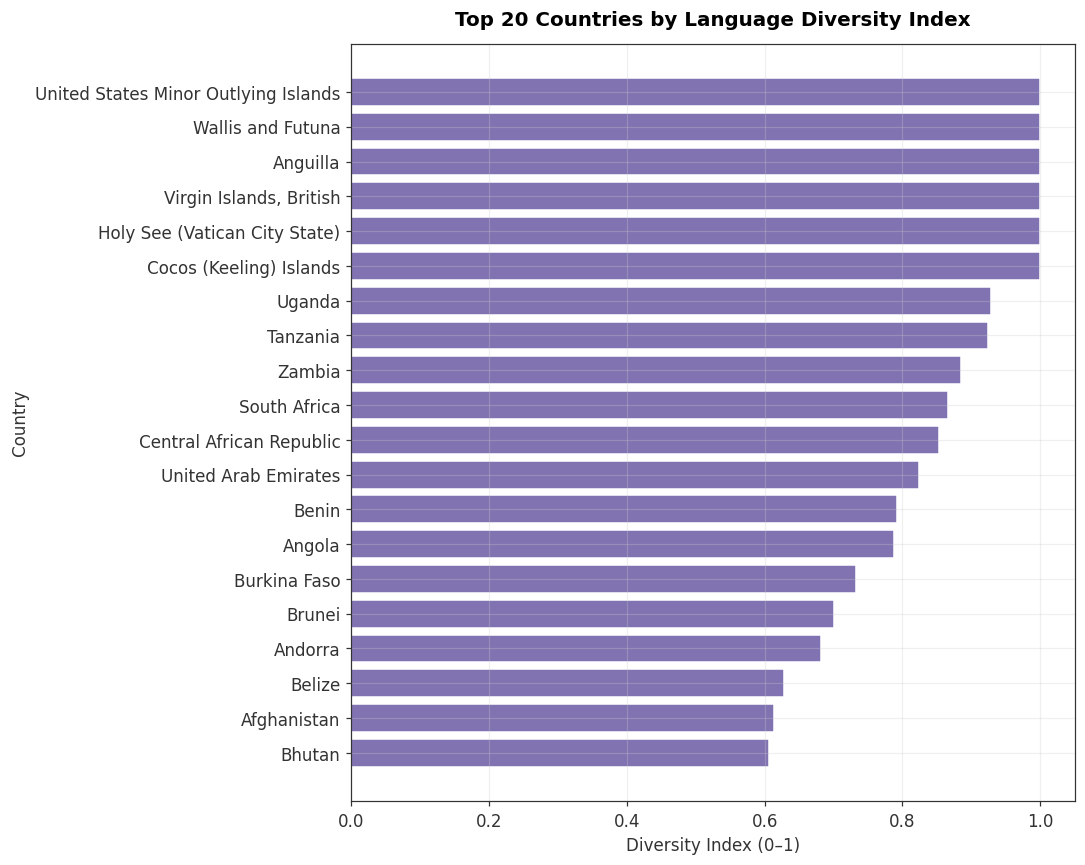

In [48]:
plot_bar(df, x='Name', y='diversity_index',
         title='Top 20 Countries by Language Diversity Index',
         xlabel='Country', ylabel='Diversity Index (0–1)',
         horizontal=True, figsize=(10, 8), color='#8172B2')

### Advanced 4 — GNP per Capita vs Life Expectancy (Scatter with Continent Hue)

**What are we doing?**  
Explore the relationship between wealth (GNP per capita) and health (life expectancy) across all countries, coloured by continent.

In [49]:
sql = """
SELECT   name,
         continent,
         lifeexpectancy,
         population,
         gnp,
         ROUND(gnp * 1000000.0 / population, 2) AS gnp_per_capita
FROM     country
WHERE    population > 0
  AND    gnp > 0
  AND    lifeexpectancy IS NOT NULL;
"""

df = run(sql)

,Name,Continent,LifeExpectancy,Population,GNP,gnp_per_capita
0,Aruba,North America,78.4,103000,828.0,8038.83
1,Afghanistan,Asia,45.9,22720000,5976.0,263.03
2,Angola,Africa,38.3,12878000,6648.0,516.23
3,Anguilla,North America,76.1,8000,63.2,7900.00
4,Albania,Europe,71.6,3401200,3205.0,942.31
5,Andorra,Europe,83.5,78000,1630.0,20897.44
6,Netherlands Antilles,North America,74.7,217000,1941.0,8944.70
7,United Arab Emirates,Asia,74.1,2441000,37966.0,15553.46
8,Argentina,South America,75.1,37032000,340238.0,9187.68
9,Armenia,Asia,66.4,3520000,1813.0,515.06


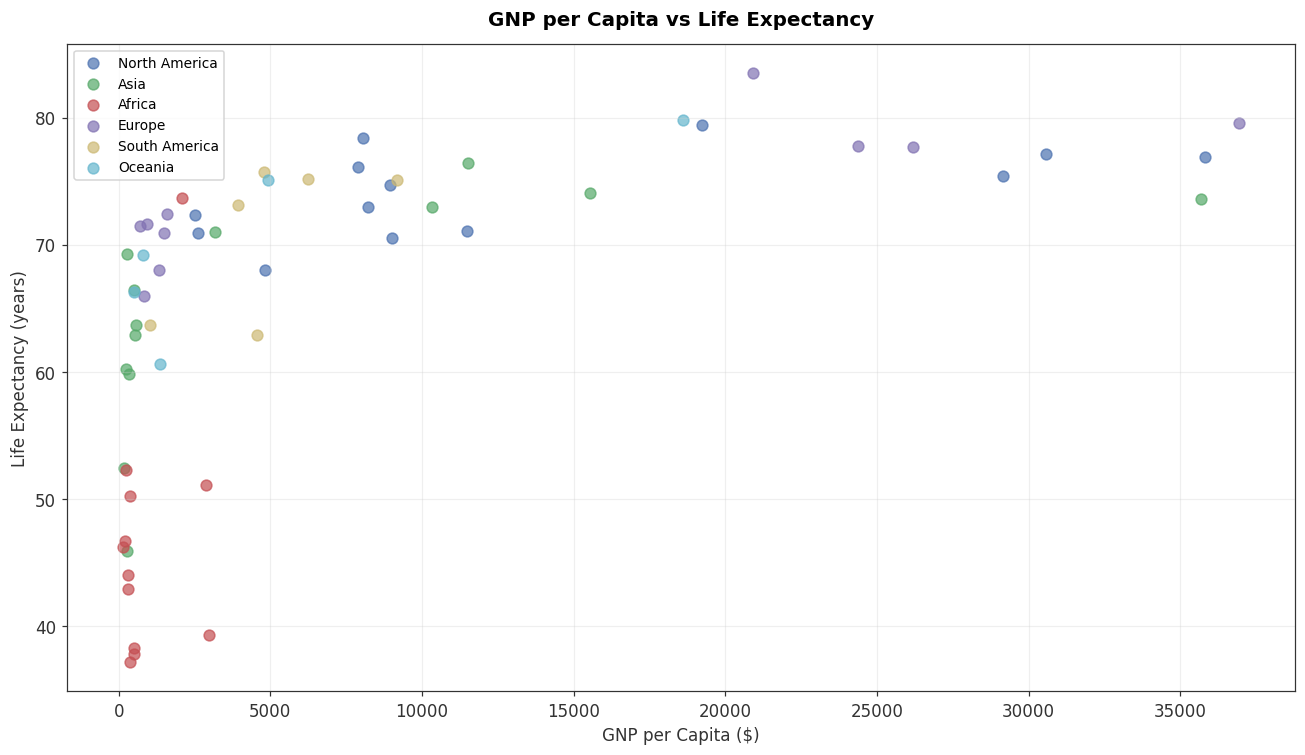

In [51]:
plot_scatter(df, x='gnp_per_capita', y='LifeExpectancy',
             hue='Continent',
             title='GNP per Capita vs Life Expectancy',
             xlabel='GNP per Capita ($)',
             ylabel='Life Expectancy (years)',
             annotate_col='name', annotate_top_n=5,
             figsize=(12, 7))

### Advanced 5 — Continent-Level Summary with Multiple Aggregations & Percentiles

**What are we doing?**  
Build a comprehensive continent dashboard using multiple aggregate functions, including median population and the 90th-percentile GNP — all in a single query with window functions.

In [52]:
sql = """
SELECT   continent,
         COUNT(*)                                          AS num_countries,
         SUM(population)                                   AS total_pop,
         ROUND(AVG(population), 0)                         AS avg_pop,
         MEDIAN(population)                                AS median_pop,
         ROUND(SUM(CAST(gnp AS DOUBLE)), 0)                AS total_gnp,
         ROUND(AVG(lifeexpectancy), 1)                     AS avg_life_exp,
         ROUND(MIN(lifeexpectancy), 1)                     AS min_life_exp,
         ROUND(MAX(lifeexpectancy), 1)                     AS max_life_exp,
         ROUND(PERCENTILE_CONT(0.9)
               WITHIN GROUP (ORDER BY CAST(gnp AS DOUBLE)), 0)
                                                           AS p90_gnp
FROM     country
WHERE    population > 0
GROUP BY continent
ORDER BY total_pop DESC;
"""

df = run(sql)

,Continent,num_countries,total_pop,avg_pop,median_pop,total_gnp,avg_life_exp,min_life_exp,max_life_exp,p90_gnp
0,Asia,13,379748000.0,29211385.0,18112000.0,610316.0,65.3,45.9,76.4,176170.0
1,North America,14,312306000.0,22307571.0,165500.0,9128843.0,74.4,68.0,79.4,421073.0
2,South America,6,258194000.0,43032333.0,19690500.0,1314351.0,71.0,62.9,75.7,558489.0
3,Africa,12,168940000.0,14078333.0,10627500.0,178622.0,46.6,37.2,73.7,18824.0
4,Europe,11,112466300.0,10224209.0,8091800.0,818787.0,73.9,66.0,83.5,249704.0
5,Oceania,7,19351600.0,2764514.0,68000.0,351924.0,70.2,60.6,79.8,140673.0


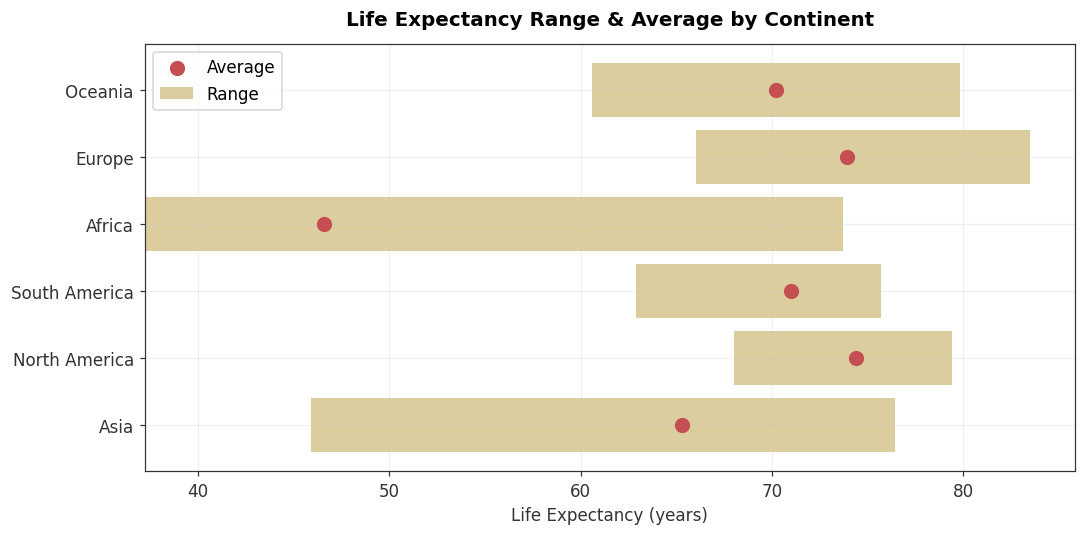

In [56]:
# Life expectancy range (min–max) per continent
life_df = df[['Continent', 'min_life_exp', 'max_life_exp', 'avg_life_exp']].copy()

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(life_df))
ax.barh(life_df['Continent'], life_df['max_life_exp'] - life_df['min_life_exp'],
        left=life_df['min_life_exp'], color='#CCB974', alpha=0.7, label='Range')
ax.scatter(life_df['avg_life_exp'], life_df['Continent'],
           color='#C44E52', s=80, zorder=5, label='Average')
ax.set_xlabel('Life Expectancy (years)')
ax.set_title('Life Expectancy Range & Average by Continent', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.show()

---
## Cleanup

In [ ]:
con.close()
print('Connection closed.')